# imports 

In [28]:
import re
from pathlib import Path
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as font_manager
from matplotlib import cm, colors
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, kendalltau, linregress
from scipy.interpolate import interp1d
import scipy.ndimage as ndi
from datetime import datetime

from mpl_toolkits.axes_grid1 import make_axes_locatable

In [29]:
# plotting parameters 
# Font sizes (increased for publication quality)
SMALL_SIZE = 12  # tick labels, legend
MEDIUM_SIZE = 14     # axis labels  
LARGE_SIZE = 16      # titles

def apply_pub_style():
    sns.set_theme(style="ticks")
    plt.rcParams.update({
        'font.size': SMALL_SIZE,           # default text size
        'axes.labelsize': MEDIUM_SIZE,     # x and y labels
        'axes.titlesize': LARGE_SIZE,      # subplot titles
        'xtick.labelsize': SMALL_SIZE,     # x tick labels
        'ytick.labelsize': SMALL_SIZE,     # y tick labels
        'legend.fontsize': SMALL_SIZE,     # legend
        'figure.titlesize': LARGE_SIZE,    # figure title
        'figure.dpi': 100,
        'savefig.dpi': 300,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Inter', 'DejaVu Sans', 'Arial'],
        'axes.linewidth': 1.0,
    })

for _inter_path in [
    "/home/rauth/.local/share/fonts/Inter-VariableFont_opsz,wght.ttf",
    "/home/rauth/.local/share/fonts/Inter-Italic-VariableFont_opsz,wght.ttf",
    "/home/rauth/.local/share/fonts/static/Inter-Bold.ttf",
    "/home/rauth/.local/share/fonts/static/Inter-BoldItalic.ttf",
]:
    if os.path.exists(_inter_path):
        font_manager.fontManager.addfont(_inter_path)

apply_pub_style()

cmap = cm.get_cmap('RdPu', 4)
anvil_color = "#B40881" 
ot_color    = "#F877A6"
storm_color = cmap(1)

/tmp/ipykernel_1857921/2474955479.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdPu', 4)


In [30]:
# load data 
final_ots = pd.read_pickle('DATA/tobac/masters_data/features/final_ots_matched_QC_v9.3.7_paper-ot_v9.3.10_paper-anvil_M1_-20_2022_03_01_2025_08_31.p')
anvil_file = 'DATA/tobac/masters_data/features/final_families_QC_v9.3.10_paper_M1_-20_2022_03_01_2025_08_31.p'
final_anvils = pd.read_pickle(anvil_file)


In [31]:
# Extract version and year range from filename for consistent naming
path = Path(anvil_file)
fname = path.name
version = re.search(r'v\d+(?:\.\d+)+', fname).group()
years = re.search(
    r'_(\d{4})_(\d{2})_(\d{2})_(\d{4})_(\d{2})_(\d{2})',
    fname
)

start_year = years.group(1)
end_year   = years.group(4)

year_range = f"{start_year}-{end_year}"
print(year_range, version)

2022-2025 v9.3.10


# table stats 

In [32]:
# Keep only anvils whose tracked_family_id_clean appears in the OT dataframe
anvils_with_ots = final_anvils[final_anvils['tracked_family_id_clean'].isin(final_ots['tracked_family_id_clean'].unique())]
total_ots = final_ots['cell'].nunique()
# Number of unique anvil cells that produced at least one OT
ot_producing_anvil_cells = anvils_with_ots["tracked_family_id_clean"].nunique()
all_anvils = final_anvils['tracked_family_id_clean'].nunique()

print(f"Results for {year_range}")
print(f"Total unique families: {all_anvils}")
print(f"Total unique OTs: {total_ots}")
print(f"Families that produced OTs: {ot_producing_anvil_cells}")
print(f"Fraction: {ot_producing_anvil_cells / all_anvils:.2%}")

Results for 2022-2025
Total unique families: 60120
Total unique OTs: 294048
Families that produced OTs: 14028
Fraction: 23.33%


In [33]:
max_lifetimes_minutes_ot = final_ots.groupby('cell')['time_cell'].apply(lambda x: x.round('T').max().total_seconds() / 60)
max_lifetimes_minutes_anvil = final_anvils.groupby('tracked_family_id_clean')['time_family'].apply(lambda x: x.round('T').max().total_seconds() / 60)


In [34]:
max_lifetimes_minutes_anvils_with_ots = anvils_with_ots.groupby('tracked_family_id_clean')['time_family'].apply(lambda x: x.round('T').max().total_seconds() / 60)


In [35]:
print(f"OTs\nMean: {max_lifetimes_minutes_ot.mean():.1f} min\nMax: {max_lifetimes_minutes_ot.max():.2f} min")

OTs
Mean: 8.5 min
Max: 180.00 min


In [36]:
print(f"Families\nMean: {max_lifetimes_minutes_anvil.mean():.1f} min\nMax: {max_lifetimes_minutes_anvil.max():.2f} min")

Families
Mean: 66.1 min
Max: 2115.00 min


In [37]:
print(f"Families with OTs\nMean: {max_lifetimes_minutes_anvils_with_ots.mean():.1f} min\nMax: {max_lifetimes_minutes_anvils_with_ots.max():.2f} min")

Families
Mean: 131.6 min
Max: 2115.00 min


Mean: 22.0
Median: 4.0
Max: 2599
Mode: 1


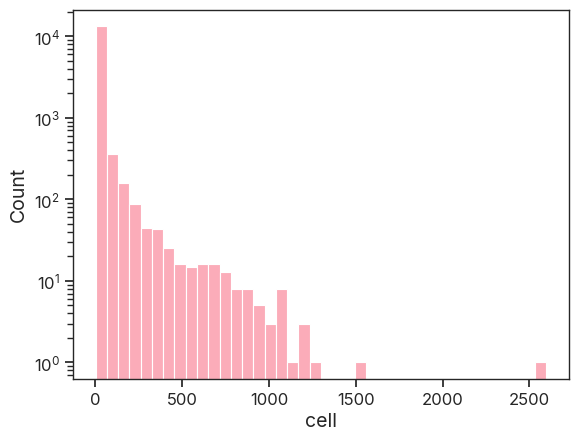

In [38]:
ot_per_anvil = final_ots.groupby(['tracked_family_id_clean'])['cell'].nunique()
ot_per_anvil_reset = ot_per_anvil.reset_index()

print(f"Mean: {np.round(ot_per_anvil_reset['cell'].mean())}\nMedian: {ot_per_anvil_reset['cell'].median()}\nMax: {ot_per_anvil_reset['cell'].max()}\nMode: {ot_per_anvil_reset['cell'].mode().values[0]}")

Mean:   1.61
Median: 1.10
Max:    28.17
Modal bin: (0.0, 1.0]


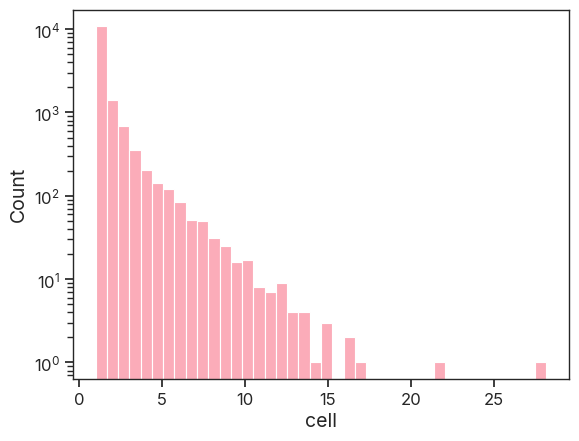

In [39]:
ots_per_timestep = (
    final_ots.groupby(["tracked_family_id_clean", "time"])["cell"]
    .count()                              # OTs active at each (storm, timestep)
    .groupby("tracked_family_id_clean")
    .mean()                               # average across timesteps for that storm
)

print(f"Mean:   {ots_per_timestep.mean():.2f}")
print(f"Median: {ots_per_timestep.median():.2f}")
print(f"Max:    {ots_per_timestep.max():.2f}")

In [40]:
x = 2 * np.sqrt(final_ots.groupby('cell')['ncells_ot'].max().mean() * 0.5**2 / np.pi)
y = 2 * np.sqrt(final_anvils.groupby('tracked_family_id_clean')['ncells_family'].max().mean() * 0.5**2 / np.pi)

print(f'mean OT diameter: {x:.2f} km' )
print(f'mean anvil diameter: {y:.2f} km')

mean OT diameter: 6.21 km
mean anvil diameter: 102.72 km


In [94]:
x = final_ots.groupby('cell')['ncells_ot'].max().mean() * 0.5**2
y = final_anvils.groupby('tracked_family_id_clean')['ncells_family'].max().mean() * 0.5**2

print(f'mean OT area: {x:.2f} km' )
print(f'mean anvil area: {y:.2f} km')

mean OT area: 30.27 km
mean anvil area: 8286.79 km


In [41]:
min_tbs = final_ots.groupby('cell')['min_tb_ot'].min()

max_heights = final_ots.groupby('cell')['trop_relative_depth'].max()

print(f'mean OT temp: {min_tbs.mean():.2f} K' )
print(f'min OT temp: {min_tbs.min():.2f} K' )
print(f'min OT height: {max_heights.min():.2f} km')
print(f'max OT height: {max_heights.max():.2f} km')
print(f'mean OT height: {max_heights.mean():.2f} km')

mean OT temp: 203.85 K
min OT temp: 178.81 K
min OT height: -5.87 km
max OT height: 6.95 km
mean OT height: 0.74 km


# general distributions 

In [43]:
x = 2 * np.sqrt(final_ots.groupby('cell')['ncells_ot'].max().median() * 0.5**2 / np.pi)
y = 2 * np.sqrt(final_anvils.groupby('tracked_family_id_clean')['ncells_family'].max().median() * 0.5**2 / np.pi)

anvil_km = final_anvils.groupby('tracked_family_id_clean')["ncells_family"].mean() * 0.5**2
ot_km = final_ots.groupby('cell')["ncells_ot"].mean() * 0.5**2

min_tbs = final_ots.groupby('cell')['min_tb_ot'].min().to_frame()
max_heights = final_ots.groupby('cell')['trop_relative_depth'].max().to_frame()

# diurnal cycle 
final_ots['time_local'] = final_ots['time'].dt.tz_localize('UTC')#.dt.tz_convert('US/Central')
final_anvils['time_local'] = final_anvils['time'].dt.tz_localize('UTC')#.dt.tz_convert('US/Central')

final_ots['hour'] = pd.to_datetime(final_ots['time_local']).dt.hour
final_anvils['hour'] = pd.to_datetime(final_anvils['time_local']).dt.hour

avg_unique_cells_anvils = final_anvils.groupby('hour')['tracked_family_id_clean'].nunique()
avg_unique_cells_ots = final_ots.groupby('hour')['cell'].nunique()

#area ratios 
ot_area_per_time = final_ots.groupby(['tracked_family_id_clean','time'])['ncells_ot'].sum()
ot_area_per_anvil = ot_area_per_time.groupby('tracked_family_id_clean').mean().to_frame()

anvil_area_per_family = final_anvils.groupby('tracked_family_id_clean')['ncells_family'].max().to_frame()

area_ratios =  anvil_area_per_family.merge(ot_area_per_anvil, on="tracked_family_id_clean", how="right")
area_ratios['ratio'] = (area_ratios.ncells_ot / area_ratios.ncells_family) *100
area_ratios = area_ratios[area_ratios.ratio <100 ]

# Grouped summary info
anvil_start     = anvils_with_ots.groupby("tracked_family_id_clean")["time"].min()
anvil_lifetime  = anvils_with_ots.groupby("tracked_family_id_clean")["time_family"].max()
first_ot_time   = final_ots.groupby("tracked_family_id_clean")["time"].min()
last_ot_time    = final_ots.groupby("tracked_family_id_clean")["time"].max()

# Ensure lifetimes in minutes
if np.issubdtype(anvil_lifetime.dtype, np.timedelta64):
    anvil_lifetime = anvil_lifetime.dt.total_seconds() / 60

# Time to first OT
first_ot_delay = (first_ot_time - anvil_start).dt.total_seconds() / 60

# Normalized delay
first_ot_delay_normalized = first_ot_delay / anvil_lifetime.loc[first_ot_delay.index]

# Compute normalized histogram (scaled to same x-axis)
counts_min, bins_min = np.histogram(first_ot_delay.dropna(), bins=np.linspace(-60, 350, 20))
mask = counts_min >= 2
counts_min_filtered = counts_min[mask]
bins_min_filtered = bins_min[:-1][mask]

duration = final_ots.groupby('tracked_family_id_clean')['timestr'].nunique()
duration = duration.dropna()
duration = duration[duration > 0]
durations_sorted = np.sort(duration)
cdf = np.arange(1, len(durations_sorted) + 1) / len(durations_sorted)
target_y = 0.50
target_x = np.interp(target_y, cdf, durations_sorted)

In [95]:
print(anvil_km.values.mean())
print(ot_km.values.mean())
print(min_tbs["min_tb_ot"].mean())
print(durations_sorted.mean(),np.median(durations_sorted),durations_sorted.max())
print(first_ot_delay.values.mean(),np.median(first_ot_delay.values))

6202.411330210185
19.368367824861586
203.85094234696425
60.65312232677502 22.0 2857
17.328439332490067 2.0469664181333336


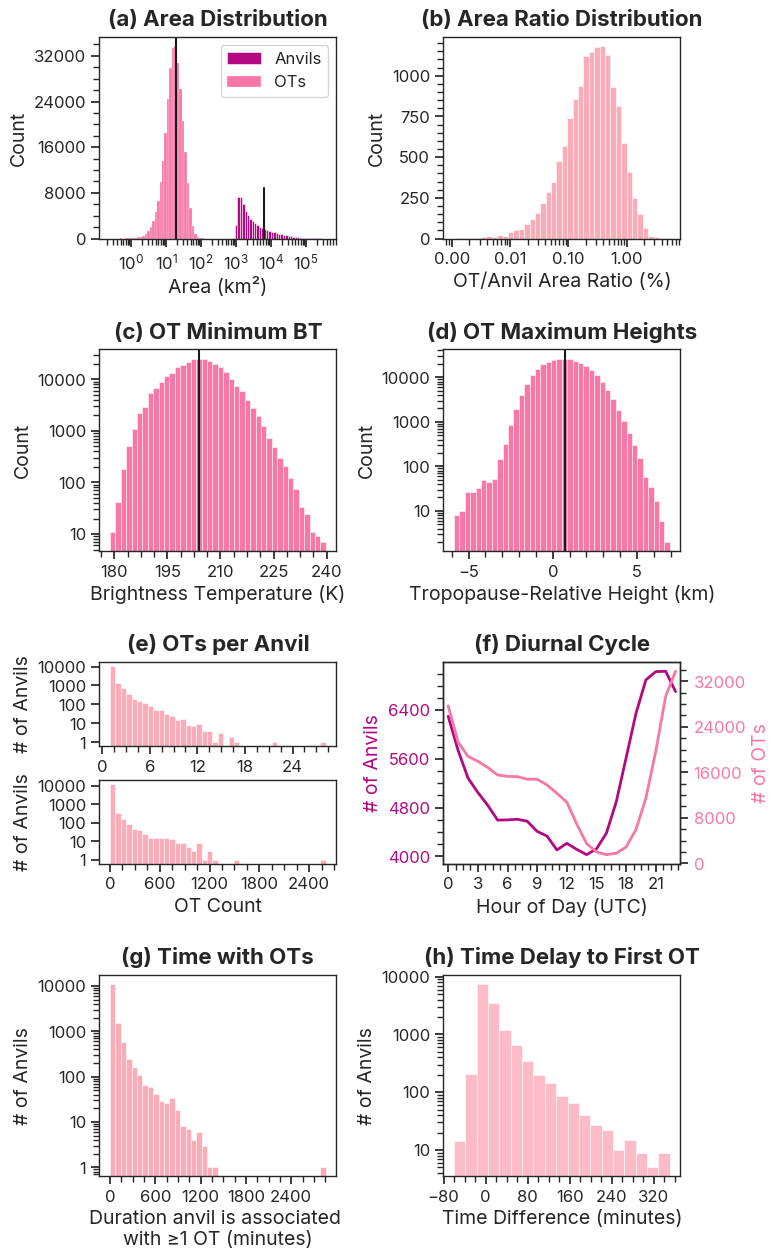

In [57]:
fig = plt.figure(figsize=(7.5, 14.8))
gs = fig.add_gridspec(4, 2, hspace = 0.55, wspace = 0.45)#, hspace=0.45, wspace=0.35)

# Panel H occupies gs[3,1] but is split into two stacked subplots
subgs = gs[2, 0].subgridspec(2, 1, hspace=0.4)

# Panel A — Area Distributions
ax1 = fig.add_subplot(gs[0, 0])

sns.histplot(anvil_km.values, log_scale=True, bins=40,
             ax=ax1, color=anvil_color, alpha=1, label="Anvils")
sns.histplot(ot_km.values, log_scale=True, bins=40,
             ax=ax1, color=ot_color, alpha=1, label="OTs")

ax1.axvline(anvil_km.values.mean(), color ='k', ymax=0.25)
ax1.axvline(ot_km.values.mean(), color ='k')
ax1.set_xlabel("Area (km²)")
ax1.set_ylabel("Count")
ax1.set_title("(a) Area Distribution", fontweight='bold', pad=8)
ax1.legend(loc='best')
ax1.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax1.xaxis.set_major_locator(mticker.LogLocator(base=10, numticks=7))
ax1.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10), numticks=12))
ax1.yaxis.set_minor_locator(mticker.AutoMinorLocator())


# Panel B — Area Ratio Distribution
ax2 = fig.add_subplot(gs[0, 1])

sns.histplot(area_ratios['ratio'].values, log_scale=True,
             bins=40, ax=ax2, color=storm_color, alpha=1)

ax2.set_xlabel("OT/Anvil Area Ratio (%)")
ax2.set_ylabel("Count")
ax2.set_title("(b) Area Ratio Distribution", fontweight='bold', pad=8)
ax2.xaxis.set_major_locator(mticker.LogLocator(base=10, numticks=5))
ax2.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10), numticks=12))
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())

# Panel C — OT Minimum BT
ax3 = fig.add_subplot(gs[1, 0])

sns.histplot(min_tbs["min_tb_ot"], bins=40,
             ax=ax3, alpha=1, color=ot_color)

ax3.set_xlabel("Brightness Temperature (K)")
ax3.set_ylabel("Count")
ax3.set_title("(c) OT Minimum BT", fontweight='bold', pad=8)
ax3.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax3.xaxis.set_minor_locator(mticker.AutoMinorLocator())
#ax3.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax3.axvline(min_tbs["min_tb_ot"].mean(), color ='k')
ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax3.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=6))
ax3.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10), numticks=12))

# Panel D — OT Maximum Heights
ax4 = fig.add_subplot(gs[1, 1])

sns.histplot(max_heights["trop_relative_depth"], bins=40,
             ax=ax4, alpha=1, color=ot_color)

ax4.set_xlabel("Tropopause-Relative Height (km)")
ax4.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax4.set_ylabel("Count")
ax4.set_title("(d) OT Maximum Heights", fontweight='bold', pad=8)
#ax4.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax4.axvline(max_heights["trop_relative_depth"].mean(), color ='k')
ax4.set_yscale('log')
ax4.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax4.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=6))
ax4.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10), numticks=12))

# Panel F — Diurnal Cycle
ax5 = fig.add_subplot(gs[2, 1])

ax5.plot(avg_unique_cells_anvils.index, avg_unique_cells_anvils.values,
         color=anvil_color, label="Anvils", linewidth=2)
ax5.set_ylabel("# of Anvils", color=anvil_color)
ax5.tick_params(axis='y', labelcolor=anvil_color)

ax5b = ax5.twinx()
ax5b.plot(avg_unique_cells_ots.index, avg_unique_cells_ots.values,
          color=ot_color, label="OTs", linewidth=2)
ax5b.set_ylabel("# of OTs", color=ot_color)
ax5b.tick_params(axis='y', labelcolor=ot_color)

ax5.set_title("(f) Diurnal Cycle", fontweight='bold', pad=8)
ax5.set_xlabel("Hour of Day (UTC)")
ax5.set_xticks(range(0, 24, 3))
ax5.set_xlim(-0.5, 23.5)
ax5.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax5.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax5b.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax5b.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax5.yaxis.set_minor_locator(mticker.AutoMinorLocator())

# Panel H — Time Delay to First OT
ax6 = fig.add_subplot(gs[3, 1])

ax6.bar(bins_min_filtered, counts_min_filtered,
        width=np.diff(bins_min)[0],
        align='edge',
        color=storm_color, edgecolor="white", alpha=0.8, linewidth=0.5)
ax6.set_yscale("log")
ax6.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax6.ticklabel_format(style='plain', axis='y')
ax6.set_ylabel("# of Anvils")
ax6.set_xlabel("Time Difference (minutes)")
ax6.set_title("(h) Time Delay to First OT", fontweight='bold', pad=8)
ax6.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=6))
ax6.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10), numticks=12))
ax6.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
ax6.xaxis.set_minor_locator(mticker.AutoMinorLocator())

# Panel G — OT Production Duration CDF
ax7 = fig.add_subplot(gs[3, 0])

target_y = 0.50
target_x = np.interp(target_y, cdf, durations_sorted)
sns.histplot(durations_sorted, bins=40,
             ax=ax7, alpha=1, color=storm_color)

ax7.set_yscale("log")
ax7.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax7.ticklabel_format(style='plain', axis='y')
ax7.set_ylabel("# of Anvils")
ax7.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=6))
ax7.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10), numticks=12))
ax7.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
ax7.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax7.set_xlabel("Duration anvil is associated \nwith ≥1 OT (minutes)")
ax7.set_title("(g) Time with OTs", fontweight='bold', pad=8)

# Panel E — OTs per Anvil (stacked)
ax8_top = fig.add_subplot(subgs[0, 0])
ax8_bot = fig.add_subplot(subgs[1, 0])

# Top — per minute
sns.histplot(ots_per_timestep, bins=40,
             ax=ax8_top, alpha=1, color=storm_color)
ax8_top.set_title("(e) OTs per Anvil", fontweight='bold', pad=8)
ax8_top.set_yscale('log')
ax8_top.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=5))
ax8_top.yaxis.set_major_formatter(ScalarFormatter())
ax8_top.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax8_top.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax8_top.set_ylabel("# of Anvils")
ax8_top.set_xlabel("")

# Bottom — cumulative
sns.histplot(ot_per_anvil, bins=40,
             ax=ax8_bot, alpha=1, color=storm_color)
ax8_bot.set_xlabel("OT Count")
ax8_bot.set_yscale('log')
ax8_bot.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=5))
ax8_bot.yaxis.set_major_formatter(ScalarFormatter())
ax8_bot.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax8_bot.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax8_bot.set_ylabel("# of Anvils")


plt.savefig(f'PLOTS/masters_paper/general_dist_{version}_{year_range}_LR3.png',
            dpi=300, bbox_inches='tight')
plt.show()

# lifetime/production trends 

## caclulations/derived quantities 

In [86]:
anvil_df = anvils_with_ots.copy()
ot_df = final_ots.copy()

# --- Normalized time and binned means ---
anvil_df["anvil_start_time"] = anvil_df["tracked_family_id_clean"].map(anvil_start)
anvil_df["anvil_lifetime"]   = anvil_df["tracked_family_id_clean"].map(anvil_lifetime)
ot_df["anvil_start_time"]    = ot_df["tracked_family_id_clean"].map(anvil_start)
ot_df["anvil_lifetime"]      = ot_df["tracked_family_id_clean"].map(anvil_lifetime)

anvil_df["normalized_time"] = (
    (anvil_df["time"] - anvil_df["anvil_start_time"]) /
    pd.to_timedelta(anvil_df["anvil_lifetime"], unit="min")
)
ot_df["normalized_time"] = (
    (ot_df["time"] - ot_df["anvil_start_time"]) /
    pd.to_timedelta(ot_df["anvil_lifetime"], unit="min")
)

bins_norm = np.linspace(0, 1, 11)
anvil_df["time_bin"] = pd.cut(anvil_df["normalized_time"], bins=bins_norm, include_lowest=True)
ot_df["time_bin"]    = pd.cut(ot_df["normalized_time"],    bins=bins_norm, include_lowest=True)

mean_area    = anvil_df.groupby("time_bin")["ncells_family"].mean() * (0.5**2)
mean_tb      = anvil_df.groupby("time_bin")["mean_tb_family"].mean()
ot_counts    = ot_df.groupby(['time_bin', "tracked_family_id_clean"])["cell"].nunique().groupby('time_bin').nunique().reindex(mean_area.index)#ot_df.groupby("time_bin")["cell"].nunique().reindex(mean_area.index)
ot_heights   = ot_df.groupby("time_bin")["trop_relative_depth"].mean().reindex(mean_area.index)
ot_areas   = ot_df.groupby("time_bin")["ncells_ot"].mean().reindex(mean_area.index) * (0.5**2)
bin_centers  = [interval.mid for interval in mean_area.index]

# Find all bins tied for the minimum
min_bins_tb = mean_tb[mean_tb == mean_tb.min()].index
max_bins_area = mean_area[mean_area == mean_area.max()].index
# Compute the midpoint spanning ALL tied minimum bins
x_min_tb = (min_bins_tb[0].left + min_bins_tb[-1].right) / 2
x_max_area = (max_bins_area[0].left + max_bins_area[-1].right) / 2


/tmp/ipykernel_1857921/1034101326.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_area    = anvil_df.groupby("time_bin")["ncells_family"].mean() * (0.5**2)
/tmp/ipykernel_1857921/1034101326.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tb      = anvil_df.groupby("time_bin")["mean_tb_family"].mean()
/tmp/ipykernel_1857921/1034101326.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ot_counts    = 

## figure: Anvil Lifetime Trends

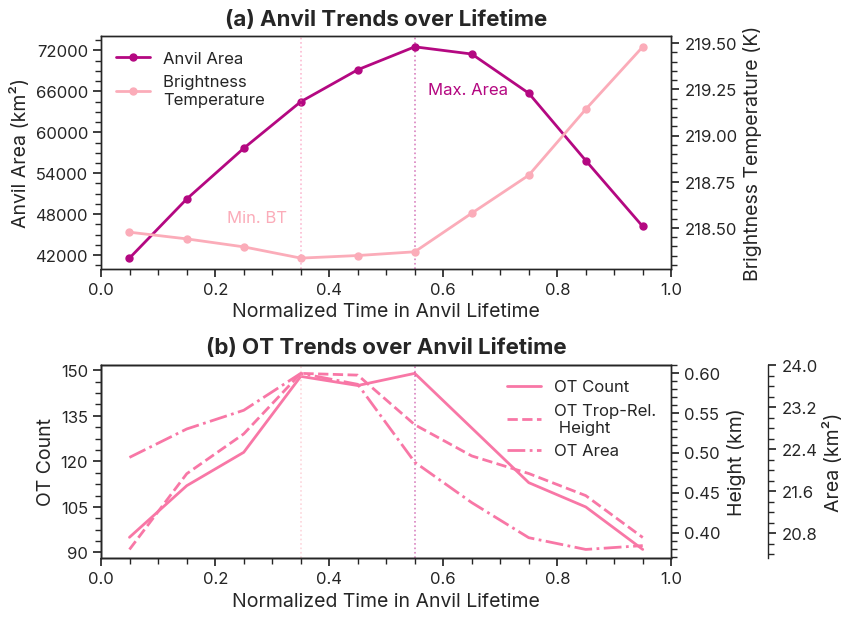

In [93]:
fig1 = plt.figure(figsize=(7.5, 6))
gs1 = gridspec.GridSpec(2, 1, height_ratios=[1.2, 1.0],
                        hspace=0.45, left=0.12, right=0.88,
                        top=0.95, bottom=0.08)

# Panel A: Anvil Area + Brightness Temperature
axB = fig1.add_subplot(gs1[0, 0])

# Primary axis: Anvil area
line1 = axB.plot(bin_centers, mean_area.values, marker="o",
                 markersize=5, color=anvil_color, label="Anvil Area (km²)",
                 linewidth=2)
axB.set_ylabel("Anvil Area (km²)")
axB.tick_params(axis='y')
axB.set_xlabel("Normalized Time in Anvil Lifetime")
axB.set_title("(a) Anvil Trends over Lifetime", fontweight='bold', pad=8)
axB.set_xlim(0, 1)

# Secondary axis: Brightness temperature
axB2 = axB.twinx()
line2 = axB2.plot(bin_centers, mean_tb.values, marker="o",
                  markersize=5, color=storm_color, label="Brightness Temperature (K)",
                  linewidth=2)
axB2.set_ylabel("Brightness Temperature (K)")
axB2.tick_params(axis='y')

# Vertical reference lines
axB.axvline(x=x_min_tb, color=ot_color, ls='dotted', lw=1.2, alpha=0.5,
            label='Min BT')
axB.axvline(x=x_max_area, color=anvil_color, ls='dotted', lw=1.2, alpha=0.5,
            label='Max Area')

axB.legend([line1[0], line2[0]], ["Anvil Area", "Brightness \nTemperature"],
           loc="upper left", frameon=False)

axB.text(0.22, 0.2, "Min. BT", color=storm_color, transform=axB.transAxes)
axB.text(0.574, .75, "Max. Area", color=anvil_color, transform=axB.transAxes)

axB.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
axB2.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
axB.xaxis.set_minor_locator(mticker.AutoMinorLocator())
axB.yaxis.set_minor_locator(mticker.AutoMinorLocator())
axB2.yaxis.set_minor_locator(mticker.AutoMinorLocator())

# Panel (B): OT Count + OT Height
axC = fig1.add_subplot(gs1[1, 0], sharex=axB)

# Primary axis: OT count
line1 = axC.plot(bin_centers, ot_counts.values, linestyle='solid',
                 color=ot_color, label="OT Count",
                 linewidth=2)
axC.set_ylabel("OT Count")
axC.tick_params(axis='y')

# Secondary axis: OT height
axC2 = axC.twinx()
line2 = axC2.plot(bin_centers, ot_heights.values, linestyle='dashed',
                  color=ot_color, label="OT Trop-Rel Height",
                  linewidth=2)
axC2.set_ylabel("Height (km)")
axC2.tick_params(axis='y')

axC3 = axC.twinx()
axC3.spines['right'].set_position(('outward', 70))
line3 = axC3.plot(bin_centers, ot_areas.values, linestyle='dashdot',
                  color=ot_color, label="OT area",
                  linewidth=2)
axC3.set_ylabel("Area (km²)")
axC3.tick_params(axis='y')

axC.set_xlabel("Normalized Time in Anvil Lifetime")
axC.set_title("(b) OT Trends over Anvil Lifetime", fontweight='bold', pad=8)

# Vertical reference lines
axC.axvline(x=x_min_tb, color=storm_color, ls='dotted', lw=1.2, alpha=0.5)
axC.axvline(x=x_max_area, color=anvil_color, ls='dotted', lw=1.2, alpha=0.5)

axC.legend([line1[0], line2[0], line3[0]], ["OT Count", "OT Trop-Rel.\n Height", "OT Area"],
           loc="upper right", frameon=False)

axC.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
axC2.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
axC3.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
axC.xaxis.set_minor_locator(mticker.AutoMinorLocator())
axC.yaxis.set_minor_locator(mticker.AutoMinorLocator())
axC2.yaxis.set_minor_locator(mticker.AutoMinorLocator())
axC3.yaxis.set_minor_locator(mticker.AutoMinorLocator())


plt.savefig(f'PLOTS/masters_paper/normalized_anvil_lifetime_trends_{version}_{year_range}_LR3.png',
            dpi=300, bbox_inches='tight')
plt.show()


# CFADS 

## calculations/derived quanities 

In [49]:
avg_cells_per_anvil = final_ots.groupby(['tracked_family_id_clean'])['cell'].nunique()
avg_area_per_family = final_anvils.groupby('tracked_family_id_clean')['ncells_family'].mean()
max_fam_lifetime = final_anvils.groupby('tracked_family_id_clean')['time_family'].max()

cell_lifetimes_per_family = final_ots.groupby(['tracked_family_id_clean', 'cell'])['time_cell'].max()
avg_lifetime_per_family = (cell_lifetimes_per_family.groupby("tracked_family_id_clean").mean())

cell_size_per_family = final_ots.groupby(['tracked_family_id_clean', 'cell'])['ncells_ot'].max()
avg_size_per_family = (cell_size_per_family.groupby("tracked_family_id_clean").mean())


cell_height_per_family = final_ots.groupby(['tracked_family_id_clean', 'cell'])['trop_relative_depth'].max()
avg_height_per_family = cell_height_per_family.groupby('tracked_family_id_clean').mean()


df = pd.DataFrame({
    'time_family': max_fam_lifetime,
    'cell_count': avg_cells_per_anvil,
    'anvil_area': avg_area_per_family,
    'time_cell': avg_lifetime_per_family,
    'cell_size': avg_size_per_family,
    'cell_height': avg_height_per_family
}).dropna()

df["time_cell_min"] = df.time_cell.dt.total_seconds() / 60.0
df["time_family_min"] = df.time_family.dt.total_seconds() / 60.0

# Convert pixel counts to km²
df["anvil_area_km2"] = df["anvil_area"] * (0.5**2)
df["ot_area_km2"]    = df["cell_size"] * (0.5**2)

df["ot_count"] = df["cell_count"] 
df["ot_area"]  = df["ot_area_km2"] 

df_filtered = df.copy() #[df["anvil_area"] >= 10]


## Figure: anvil/OT relationships

In [50]:
plt.rcdefaults()
apply_pub_style()

Panel 0: x=OT Area (km²), y=Anvil Area (km²), r=0.880, β=0.01234
Panel 1: x=OT Area (km²), y=Anvil Lifetime (min), r=0.682, β=0.00473
Panel 2: x=OT Count, y=Anvil Area (km²), r=0.853, β=0.002879
Panel 3: x=OT Count, y=Anvil Lifetime (min), r=0.872, β=0.002282
Panel 4: x=OT Lifetime (min), y=Anvil Area (km²), r=-0.244, β=-0.005132
Panel 5: x=OT Lifetime (min), y=Anvil Lifetime (min), r=-0.194, β=-0.00402
Panel 6: x=Trop-Relative OT Height (km), y=Anvil Area (km²), r=0.891, β=0.1642
Panel 7: x=Trop-Relative OT Height (km), y=Anvil Lifetime (min), r=0.852, β=0.05182


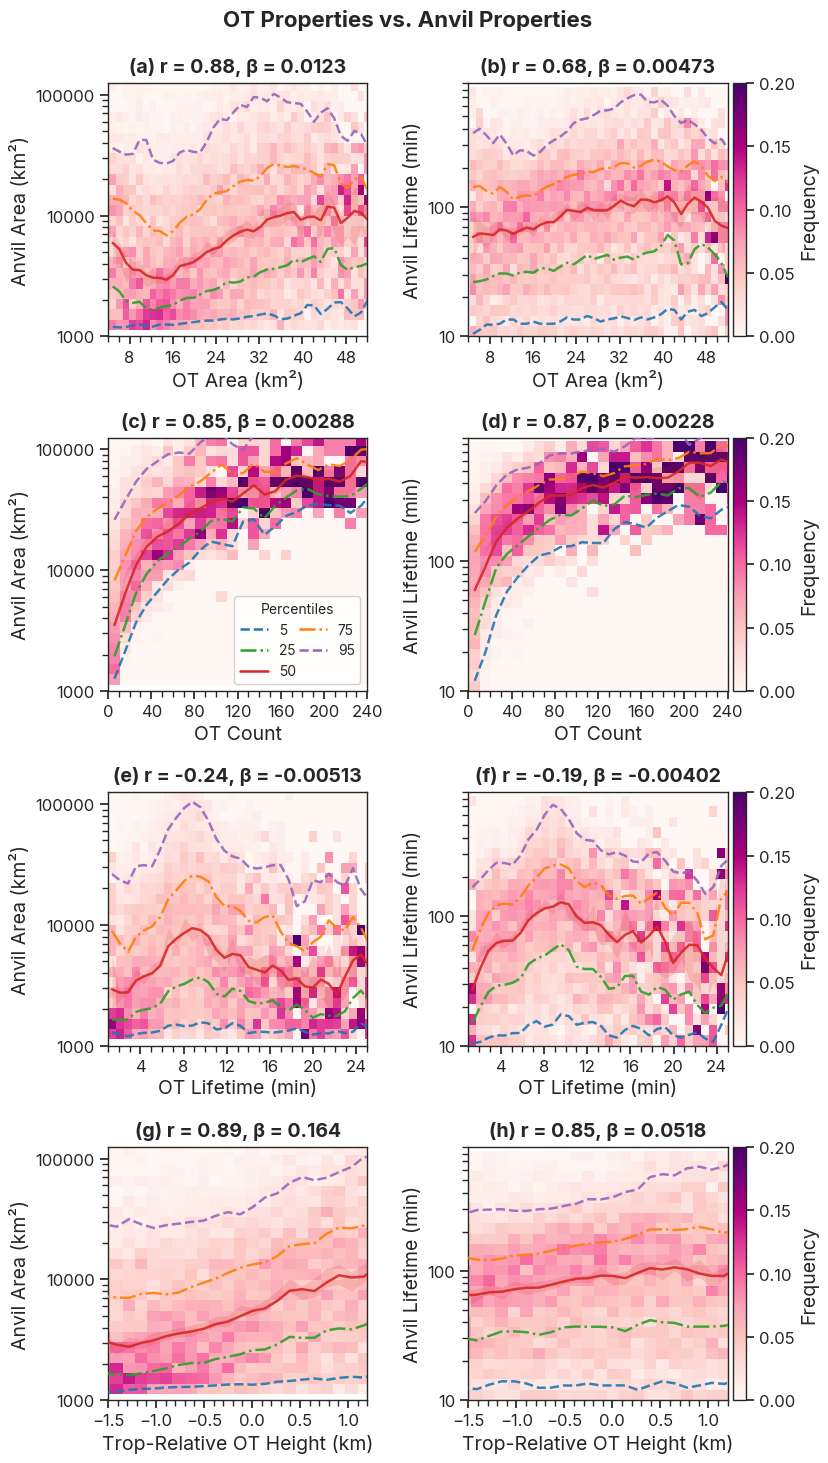

In [51]:
def compute_percentile_lines(x, y, xedges, percentiles=[5, 25, 50, 75, 95],
                              min_samples=5, smooth_window=2):
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    perc_arrays = {p: [] for p in percentiles}
    for i in range(len(xedges) - 1):
        mask = (x >= xedges[i]) & (x < xedges[i + 1])
        ybin = y[mask]
        if len(ybin) >= min_samples:
            for p in percentiles:
                perc_arrays[p].append(np.nanpercentile(ybin, p))
        else:
            for p in percentiles:
                perc_arrays[p].append(np.nan)
    if smooth_window > 1:
        for p in percentiles:
            arr = np.array(perc_arrays[p], dtype=float)
            arr = ndi.uniform_filter1d(arr, size=smooth_window, mode="nearest")
            perc_arrays[p] = arr
    return xcenters, perc_arrays

def bootstrap_percentile_ci(x, y, xedges, percentile=50, n_boot=300):
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    y_low, y_high = [], []
    for i in range(len(xedges) - 1):
        mask = (x >= xedges[i]) & (x < xedges[i + 1])
        ybin = y[mask]
        if len(ybin) < 3:
            y_low.append(np.nan)
            y_high.append(np.nan)
            continue
        boots = [np.nanpercentile(np.random.choice(ybin, size=len(ybin), replace=True), percentile)
                 for _ in range(n_boot)]
        y_low.append(np.nanpercentile(boots, 5))
        y_high.append(np.nanpercentile(boots, 95))
    return xcenters, np.array(y_low), np.array(y_high)



fig, axes = plt.subplots(4, 2, figsize=(7.5, 14.8))
plt.subplots_adjust(left=0.10, right=0.95, top=0.94, bottom=0.05,
                    hspace=0.40, wspace=0.3)
axes = axes.ravel()

# Shared x-variable definitions (one per row, applied to both columns)
x_vars = [
    (df_filtered["ot_area"],       "OT Area (km²)"),
    (df_filtered["ot_count"],      "OT Count"),
    (df_filtered["time_cell_min"], "OT Lifetime (min)"),
    (df_filtered["cell_height"],   "Trop-Relative OT Height (km)"),
]

# y-variables per column
y_area     = (df_filtered["anvil_area_km2"], "Anvil Area (km²)")
y_lifetime = (df_filtered["time_family_min"],   "Anvil Lifetime (min)")

# Build flat plot_data list in row-major order:
# panel index = row*2 + col  →  col 0 = anvil area, col 1 = anvil lifetime
plot_data = []
for x_ser, x_lbl in x_vars:
    for y_ser, y_lbl in [y_area, y_lifetime]:
        plot_data.append((x_ser, y_ser, x_lbl, y_lbl))

# x-limits (one per row, shared across both columns)
xlimits_per_row = [
    (4, 52),      # OT Area
    (0, 240),     # OT Count
    (1, 25),      # OT Lifetime
    (-1.5, 1.2),  # OT Height
]
# Expand to per-panel list matching plot_data order
xlimits = [lim for lim in xlimits_per_row for _ in range(2)]

# y-limits per column
ylims = {0: (1000, 125000), 1: (10, 900)}   # col 0 = area, col 1 = lifetime

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

# Percentile settings
percentiles = [5, 25, 50, 75, 95]
colors      = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd']
styles      = ['--', '-.', '-', '-.', '--']
min_samples  = 5
smooth_window = 2
n_boot       = 300
ci_alpha     = 0.15

#compute histograms; derive separate vmax per column
all_H_norm = []
all_edges  = []

for i, (x, y, xlabel, ylabel) in enumerate(plot_data):
    mask = (y > 0)
    x, y = x[mask], y[mask]
    if len(x) < 10:
        all_H_norm.append(None)
        all_edges.append(None)
        continue

    xedges = np.linspace(np.nanpercentile(x, 1), np.nanpercentile(x, 99), 40)
    yedges = np.logspace(np.log10(np.percentile(y, 1)),
                         np.log10(np.percentile(y, 99)), 25)

    H, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])
    H = np.nan_to_num(H)
    with np.errstate(invalid='ignore', divide='ignore'):
        H_norm = H / H.sum(axis=1, keepdims=True)
    H_norm = np.nan_to_num(H_norm)
    all_H_norm.append(H_norm)
    all_edges.append((xedges, yedges))

# Separate global vmax for each column so colorbars are meaningful
def col_vmax(col):
    vals = [np.nanpercentile(all_H_norm[i], 95)
            for i in range(col, len(plot_data), 2)
            if all_H_norm[i] is not None]
    return max(vals)

global_vmax_col = {0: col_vmax(0), 1: col_vmax(1)}
vmin = 0.0

# plotting
for i, (ax, (x, y, xlabel, ylabel)) in enumerate(zip(axes, plot_data)):
    col = i % 2
    mask = (y > 0)
    x, y = x[mask], y[mask]

    if len(x) < 10:
        ax.text(0.5, 0.5, "Insufficient data", transform=ax.transAxes,
                ha="center", va="center")
        continue

    xedges, yedges = all_edges[i]
    H_norm = all_H_norm[i]

    pcm = ax.pcolormesh(
        xedges, yedges, H_norm.T,
        cmap="RdPu", vmin=vmin, vmax=global_vmax_col[col],
        shading="auto", zorder=1, rasterized=True
    )

    # Colorbar on right column
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    if col == 1:
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label("Frequency")
    else:
        cax.axis('off')

    # Percentile curves
    xcenters, perc_lines = compute_percentile_lines(
        x, y, xedges, percentiles=percentiles,
        min_samples=min_samples, smooth_window=smooth_window
    )

    for p, color, style in zip(percentiles, colors, styles):
        ax.plot(xcenters, perc_lines[p], style, color=color,
                lw=1.8, zorder=4, alpha=0.9)
        if p == 50:
            xc_boot, y_low, y_high = bootstrap_percentile_ci(
                x, y, xedges, percentile=p, n_boot=n_boot
            )
            ax.fill_between(xc_boot, y_low, y_high,
                            color=color, alpha=ci_alpha, linewidth=0, zorder=3)

    # Correlation / slope on median
    median_vals = perc_lines[50]
    valid = ~np.isnan(median_vals)
    if valid.sum() >= 3:
        x_med = xcenters[valid]
        logy  = np.log10(median_vals[valid])
        r     = np.corrcoef(x_med, logy)[0, 1]
        beta  = linregress(x_med, logy).slope
        print(f"Panel {i}: x={xlabel}, y={ylabel}, r={r:.3f}, β={beta:.4g}")
        ax.set_title(f"{panel_labels[i]} r = {r:.2f}, β = {beta:.3g}",
                     fontweight='bold', fontsize=MEDIUM_SIZE, pad=8)

    # Axis formatting
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # y-axis label only for left column
    if col == 0:
        ax.set_ylabel(ylabel)
    else:
        ax.set_yticklabels([])

    ax.set_ylim(*ylims[col])
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="y")
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=6))
    ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10), numticks=12))
    ax.set_xlim(xlimits[i])
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())

# Percentile legend in top-right panel
legend_lines = [Line2D([0], [0], color=c, ls=s, lw=1.8)
                for c, s in zip(colors, styles)]
axes[2].legend(legend_lines, [str(p) for p in percentiles],
               loc="lower right", fontsize=10, title="Percentiles",
               frameon=True, framealpha=0.9, ncol=2,
               title_fontsize=10, columnspacing=0.2)

fig.suptitle("OT Properties vs. Anvil Properties", fontweight='bold', y=0.99)

plt.savefig(f"PLOTS/masters_paper/anvil_combined_2dhists_{version}_{year_range}_LR3.png",
            dpi=300, bbox_inches="tight")
plt.show()

# OT correlations 

In [52]:
family_df = pd.DataFrame({

    "OT Area (km²)": final_ots.groupby("tracked_family_id_clean")["ncells_ot"].mean() * 0.5**2,
    "OT Height (km)": final_ots.groupby('tracked_family_id_clean')['trop_relative_depth'].max(),
    "OT Lifetime (min)": (
        final_ots.groupby(['tracked_family_id_clean', "cell"])["time_family"]
        .max()
        .groupby('tracked_family_id_clean').mean().dt.total_seconds() / 60.0
    ),
    "OT Brightness Temp. (K)": final_ots.groupby("tracked_family_id_clean")["min_tb_ot"].min()
    
})

family_df = family_df.apply(pd.to_numeric, errors="coerce").dropna()
corr_p = family_df.corr(method="pearson")

In [53]:
REGIONS = {
    "midlat":  final_ots[final_ots["latitude"] >  30],
    "tropics": final_ots[final_ots["latitude"] <= 23.5],
    "all": final_ots,
}

# Build per-region DataFrame
def build_ot_df(df: pd.DataFrame) -> pd.DataFrame:
    grp = df.groupby("tracked_family_id_clean")
    lifetime = (
        df.groupby(["tracked_family_id_clean", "cell"])["time_family"]
        .max()
        .groupby("tracked_family_id_clean").mean()
        .dt.total_seconds() / 60.0
    )
    return pd.DataFrame({
        "OT Area (km²)":           grp["ncells_ot"].mean() * 0.5**2,
        "OT Height (km)":          grp["trop_relative_depth"].max(),
        "OT Lifetime (min)":       lifetime,
        "OT Brightness Temp. (K)": grp["min_tb_ot"].min(),
    }).apply(pd.to_numeric, errors="coerce").dropna()

region_dfs   = {name: build_ot_df(df) for name, df in REGIONS.items()}
region_corrs = {name: df.corr(method="pearson") for name, df in region_dfs.items()}

# Regression pairs: (x_col, y_col, short_label)
PAIRS = [
    ("OT Brightness Temp. (K)", "OT Height (km)",    "th"),
    ("OT Brightness Temp. (K)", "OT Area (km²)",     "ta"),
    ("OT Area (km²)",           "OT Height (km)",    "ah"),
    ("OT Lifetime (min)",       "OT Height (km)",    "lh"),
]

results = {}
for region, df in region_dfs.items():
    results[region] = {}
    for x_col, y_col, label in PAIRS:
        x, y = df[x_col], df[y_col]
        slope, intercept, r, p, se = linregress(x, y)
        results[region][label] = dict(
            slope=slope, intercept=intercept,
            r=r, p=p, se=se,
            x_range=np.linspace(x.min(), x.max(), 100),
        )

/tmp/ipykernel_1857921/771986706.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(0.525, 0.97, f"({panel['label']}) r = {corr_p['OT Brightness Temp. (K)'][1]:.3f}\n\n",


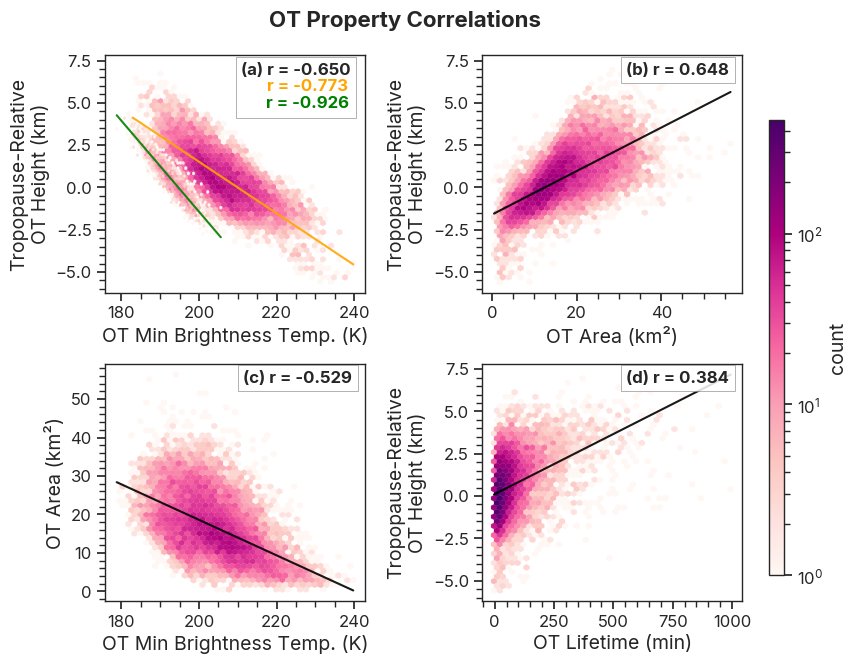

In [91]:
PANELS = [
    dict(pos=(0,0), label="a", x_col="OT Brightness Temp. (K)", y_col="OT Height (km)", pair="th"),
    dict(pos=(0,1), label="b", x_col="OT Area (km²)",           y_col="OT Height (km)", pair="ah"),
    dict(pos=(1,0), label="c", x_col="OT Brightness Temp. (K)", y_col="OT Area (km²)",  pair="ta"),
    dict(pos=(1,1), label="d", x_col="OT Lifetime (min)",       y_col="OT Height (km)", pair="lh"),
]

REGION_STYLE = {
    "midlat":  dict(cmap="RdPu",      line_color="orange"),
    "tropics": dict(cmap="RdPu", line_color="green"),
    "all":     dict(cmap="RdPu",     line_color="black"),
}

AXIS_LABELS = {
    "OT Brightness Temp. (K)": "OT Min Brightness Temp. (K)",
    "OT Area (km²)":           "OT Area (km²)",
    "OT Lifetime (min)":       "OT Lifetime (min)",
    "OT Height (km)":          "Tropopause-Relative\nOT Height (km)",
}

fig, axes = plt.subplots(2, 2, figsize=(7.5, 6.5))
plt.subplots_adjust(left=0.10, right=0.95, top=0.92, bottom=0.08,
                    hspace=0.3, wspace=0.45)

hbs_mid = []
hbs_trop = []

for panel in PANELS:
    ax   = axes[panel["pos"]]
    pair = panel["pair"]

    r_vals = {}

    # midlat + tropics separately
    if panel["label"] == "a":
        regions_to_plot = ["midlat", "tropics"]

    # full dataset
    else:
        regions_to_plot = ["all"]

    r_vals = {}
    for region in regions_to_plot:
        style = REGION_STYLE[region]
        df    = region_dfs[region]
        stats = results[region][pair]
        x, y  = df[panel["x_col"]], df[panel["y_col"]]

        hb = ax.hexbin(x, y, gridsize=40, mincnt=1, bins="log",
                       cmap=style["cmap"], linewidths=0.2, edgecolors="face")
        ax.plot(stats["x_range"],
                stats["slope"] * stats["x_range"] + stats["intercept"],
                lw=1.5, color=style["line_color"], alpha=0.9)

        if region == "tropics":
            hbs_trop.append(hb)
        else:
            hbs_mid.append(hb)   

        r_vals[region] = stats["r"]

    # Annotations
    if panel["label"] == "a":
        ax.text(0.525, 0.97, f"({panel['label']}) r = {corr_p['OT Brightness Temp. (K)'][1]:.3f}\n\n",
                transform=ax.transAxes, ha="left", va="top",
                fontweight="bold", bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray",
                      linewidth=0.5, pad=4))

        ax.text(0.935, 0.9, f"r = {r_vals['midlat']:.3f}",
                transform=ax.transAxes, ha="right", va="top",
                color="orange", fontweight="bold")

        ax.text(0.94, 0.83, f"r = {r_vals['tropics']:.3f}",
                transform=ax.transAxes, ha="right", va="top",
                color="green", fontweight="bold")
    else:
        ax.text(0.95, 0.97, f"({panel['label']}) r = {r_vals['all']:.3f}",
                transform=ax.transAxes, ha="right", va="top", fontweight="bold",
                bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray", linewidth=0.5, pad=4))
    
    # Common styling
    ax.set_xlabel(AXIS_LABELS[panel["x_col"]])
    ax.set_ylabel(AXIS_LABELS[panel["y_col"]])
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

height_axes = [axes[p["pos"]] for p in PANELS if p["y_col"] == "OT Height (km)"]
y_min = min(ax.get_ylim()[0] for ax in height_axes)
y_max = max(ax.get_ylim()[1] for ax in height_axes)
for ax in height_axes:
    ax.set_ylim(y_min, y_max)

all_hbs = hbs_mid + hbs_trop

vmin = min(hb.get_array().min() for hb in all_hbs)
vmax = max(hb.get_array().max() for hb in all_hbs)

for hb in all_hbs:
    hb.set_clim(vmin, vmax)

cbar_ax_bot = fig.add_axes([0.985, 0.12, 0.02, 0.70]) 
fig.colorbar(hbs_mid[0], cax=cbar_ax_bot, label="count")

fig.suptitle("OT Property Correlations", fontweight="bold", y=0.99)
plt.savefig(f'PLOTS/masters_paper/ot_family_corr_hexes_{version}_{year_range}_LR3.png', 
            dpi=300, bbox_inches='tight')
plt.show()